In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
df=pd.read_csv("C:/Users/adaml/OneDrive/Documents/Data Projects/9 Projects for ITonlinelearning portfolio/titanic.csv")

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [6]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
age_mean = df['Age'].mean()
age_median = df['Age'].median()
age_std_deviation = df['Age'].std()

print(f"Mean Age:{age_mean}")
print(f"Median Age:{age_median}")
print(f"Standard Deviation of Age:{age_std_deviation}")

Mean Age:29.69911764705882
Median Age:28.0
Standard Deviation of Age:14.526497332334042


In [9]:
df['Family Size']=df['SibSp'] + df['Parch'] + 1 # +1 to include the passenger themself
df['Family Size']

0      2
1      2
2      1
3      2
4      1
      ..
886    1
887    1
888    4
889    1
890    1
Name: Family Size, Length: 891, dtype: int64

In [13]:
# Rename 'Fare' column to 'Ticket Price'
df=df.rename(columns={
    'Fare':'Ticket Price',
    'SibSp':'Siblings/Spouses Aboard',
    'Parch':'Parents/Children Aboard',
    'Pclass':'Passenger Class',
    'Name':'Full Name'})
df

,PassengerId,Survived,Passenger Class,Full Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Ticket,Ticket Price,Cabin,Embarked,Family Size
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,1
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,4
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,1


In [14]:
# Drop rows where age is less than 18 years old.
df=df.drop(df.loc[df['Age']<18].index)

In [15]:
# Adding a new row
df2 = {'Survived':  0, 
       'Passenger Class': 3, 
       'Full Name': 'Harry', 
       'Sex': 'male', 
       'Age': 30, 
       'Siblings/Spouses Aboard': 0, 
       'Parents/Children Aboard': 2, 
       'Ticket Price': 50.00, 
       'Family Size': 3
    }

df=pd.concat([df, pd.DataFrame(df2, index=[0])], ignore_index=True)

In [16]:
# Create a new dataframe named 'filtered_df' 
filtered_df= df.loc[(df['Passenger Class']==1)&(df['Ticket Price']>100)]
filtered_df

,PassengerId,Survived,Passenger Class,Full Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Ticket,Ticket Price,Cabin,Embarked,Family Size
20,28.0,0,1,"Fortune, Mr. Charles Alexander",male,19.0,3,2,19950,263.0000,C23 C25 C27,S,6
24,32.0,1,1,"Spencer, Mrs. William Augustus (Marie Eugenie)",female,NaN,1,0,PC 17569,146.5208,B78,C,2
70,89.0,1,1,"Fortune, Miss. Mabel Helen",female,23.0,3,2,19950,263.0000,C23 C25 C27,S,6
98,119.0,0,1,"Baxter, Mr. Quigg Edmond",male,24.0,0,1,PC 17558,247.5208,B58 B60,C,2
161,196.0,1,1,"Lurette, Miss. Elise",female,58.0,0,0,PC 17569,146.5208,B80,C,1
179,216.0,1,1,"Newell, Miss. Madeleine",female,31.0,1,0,35273,113.2750,D36,C,2
219,259.0,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,NaN,C,1
227,269.0,1,1,"Graham, Mrs. William Thompson (Edith Junkins)",female,58.0,0,1,PC 17582,153.4625,C125,S,2
228,270.0,1,1,"Bissette, Miss. Amelia",female,35.0,0,0,PC 17760,135.6333,C99,S,1
255,300.0,1,1,"Baxter, Mrs. James (Helene DeLaudeniere Chaput)",female,50.0,0,1,PC 17558,247.5208,B58 B60,C,2


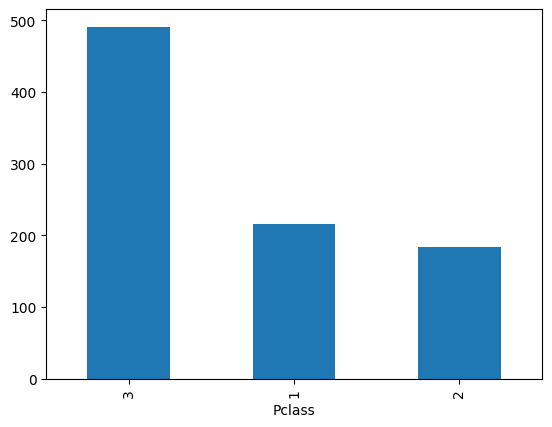

In [18]:
#Create new bar chart
new_df=pd.read_csv("C:/Users/adaml/OneDrive/Documents/Data Projects/9 Projects for ITonlinelearning portfolio/titanic.csv")
counts=new_df['Pclass'].value_counts()
counts.plot(kind='bar')
plt.show()

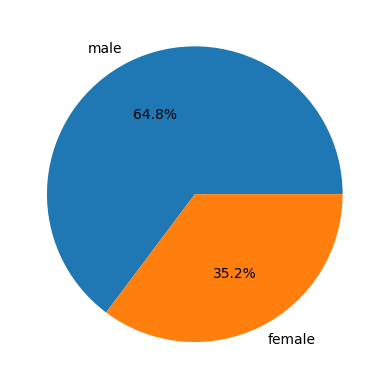

In [19]:
#Create Pie Chart
gender_counts = new_df['Sex'].value_counts()
gender_counts.plot(kind='pie', autopct='%1.1f%%')
plt.show()